# Glitter (PIV) — visualización de un análisis

Lee lo que guarda **ANALIZAR TODO** (TouchDesigner) en `fluido/data glitter/`:

- `<grabación>_parametros.json`: calibración, tiempos y parámetros del PIV de cada cámara.
- `<grabación>_camara<L>_campo.csv`: una fila por vector de cada par de cuadros
  (`frame, t_s, x_px, y_px, x_mm, y_mm, u_mm_s, v_mm_s, interpolado`).

Todo se pasa a **cm** con la calibración hecha en TouchDesigner. Si una cámara no se calibró,
sus gráficos quedan en px y se avisa. El origen está abajo a la izquierda con `y` hacia arriba,
así que un giro antihorario tiene `v_θ > 0`.

Correr las celdas en orden. Lo único para tocar son las variables en MAYÚSCULAS.

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
fontsize = 13
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "mathtext.default": "regular",
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)
AZUL, NARANJA = "#2A6FB5", "#E08A2E"

DATA = Path("../data glitter")

analisis = sorted(DATA.glob("*_parametros*.json"), key=lambda p: p.stat().st_mtime)
for i, p in enumerate(analisis):
    print(f"{i - len(analisis):4d}   {p.name}")

  -1   2026-09-14_135212_SIMULACION_parametros.json


## 1. Cargar

- `CUAL`: el número de la lista de arriba (`-1` = el análisis más reciente).
- `SACAR_INTERPOLADOS`: dejar afuera de los promedios los vectores que la validación descartó
  y rellenó con sus vecinos.

Para cada vector se calcula la posición respecto del centro del vórtice marcado en
TouchDesigner (`dx, dy, r`) y las velocidades tangencial `vt` y radial `vr`.

In [3]:
CUAL = -1
SACAR_INTERPOLADOS = True

P = json.loads(analisis[CUAL].read_text(encoding="utf-8"))
info = P["grabacion_info"]


def cargar(L, cam):
    cal = cam["calibracion"]
    calibrada = cal["mm_por_px"] is not None
    k = 0.1 if calibrada else 1.0                    # mm -> cm (sin calibrar, las columnas "mm" estan en px)
    s = cal["mm_por_px"] * k if calibrada else 1.0   # cm (o px) por px

    todo = pd.read_csv(DATA / cam["csv"])
    todo["x"], todo["y"] = todo["x_mm"] * k, todo["y_mm"] * k
    todo["u"], todo["v"] = todo["u_mm_s"] * k, todo["v_mm_s"] * k

    cx, cy = np.array(cal["centro_vortice_px"]) * s
    todo["dx"], todo["dy"] = todo["x"] - cx, todo["y"] - cy
    todo["r"] = np.hypot(todo["dx"], todo["dy"])
    r = todo["r"].where(todo["r"] > 0)
    todo["vt"] = (todo["v"] * todo["dx"] - todo["u"] * todo["dy"]) / r
    todo["vr"] = (todo["u"] * todo["dx"] + todo["v"] * todo["dy"]) / r

    return dict(
        todo=todo,
        df=todo[todo["interpolado"] == 0] if SACAR_INTERPOLADOS else todo,
        unidad="cm" if calibrada else "px",
        s=s, cx=cx, cy=cy, R=cal["radio_roi_px"] * s,
        paso=np.diff(np.unique(todo["x"])).min(),    # separacion entre nodos de la grilla
        vista=cam["vista"],
        eje_vertical="z" if "lateral" in cam["vista"] else "y",
        sim=info.get("camaras", {}).get(L, info).get("simulacion"),
        meta=cam,
    )


camaras = {L: cargar(L, cam) for L, cam in sorted(P["camaras"].items())}

print(f"grabación : {P['grabacion']}")
print(f"agitador  : {info.get('velocidad_agitador_rpm')} rpm")
print(f"análisis  : {P['fecha_analisis']}" + ("   (detenido a mano)" if P["detenido_a_mano"] else ""))
for L, c in camaras.items():
    if c["unidad"] == "px":
        print(f"\n¡OJO! la cámara {L} no está calibrada: sus gráficos quedan en px.")

pd.DataFrame({
    f"cámara {L}": {
        "vista": c["vista"],
        "pares analizados": c["meta"]["pares_analizados"],
        "completo": c["meta"]["completo"],
        "fps": round(c["meta"]["tiempo"]["fps"], 2),
        "cuadros perdidos": c["meta"]["tiempo"]["cuadros_perdidos"],
        "vectores por par": c["meta"]["vectores_por_par"],
        "interpolados [%]": round(c["meta"]["interpolados_pct"], 2),
        "escala": f"{c['s'] * 1e4:.1f} µm/px" if c["unidad"] == "cm" else "sin calibrar",
        "centro": f"({c['cx']:.2f}, {c['cy']:.2f}) {c['unidad']}",
        "radio analizado": f"{c['R']:.2f} {c['unidad']}",
    }
    for L, c in camaras.items()
})

grabación : GRABACIONES/2026-09-14_135212_SIMULACION
agitador  : 0.0 rpm
análisis  : 2026-09-15 16:41:17   (detenido a mano)


,cámara A
vista,"superior (x, y)"
pares analizados,39
completo,False
fps,39.82
cuadros perdidos,0
vectores por par,1222
interpolados [%],0.12
escala,191.1 µm/px
centro,"(12.21, 6.95) cm"
radio analizado,6.33 cm


## 2. Campo medio

Promedio temporal de todos los pares en cada nodo de la grilla. A la izquierda, el módulo de la
velocidad con los vectores; a la derecha, la vorticidad normal a la imagen `∂v/∂x − ∂u/∂y`
(en un vórtice de Rankine vale `2ω` en el núcleo y cero afuera).
La cruz es el centro marcado y el círculo punteado, la región analizada.

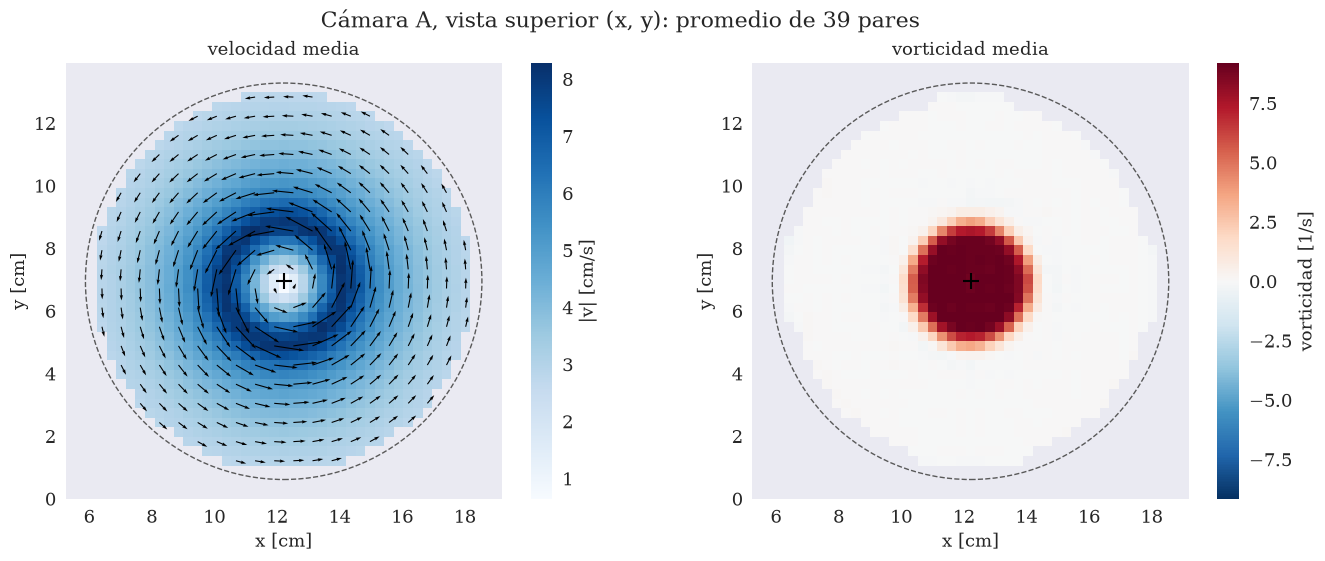

In [4]:
PASO_FLECHAS = 2   # una flecha cada tantos nodos


def grilla(df):
    # Promedio temporal por nodo, como matrices 2D (fila = y, columna = x)
    xs, ys = np.unique(df["x"]), np.unique(df["y"])
    m = df.groupby(["y", "x"])[["u", "v"]].mean().reindex(pd.MultiIndex.from_product([ys, xs]))
    U = m["u"].to_numpy().reshape(len(ys), len(xs))
    V = m["v"].to_numpy().reshape(len(ys), len(xs))
    return xs, ys, U, V


def decorar(ax, c):
    ax.add_patch(plt.Circle((c["cx"], c["cy"]), c["R"], fill=False, ls="--", lw=1, color="0.35"))
    ax.plot(c["cx"], c["cy"], "k+", ms=12, mew=1.5)
    ax.set_aspect("equal")
    ax.grid(False)
    ax.set_xlabel(f"x [{c['unidad']}]")
    ax.set_ylabel(f"{c['eje_vertical']} [{c['unidad']}]")


for L, c in camaras.items():
    xs, ys, U, V = grilla(c["df"])
    X, Y = np.meshgrid(xs, ys)
    rapidez = np.hypot(U, V)
    vorticidad = np.gradient(V, xs, axis=1) - np.gradient(U, ys, axis=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

    im = ax1.pcolormesh(X, Y, rapidez, cmap="Blues", shading="nearest")
    fig.colorbar(im, ax=ax1, label=f"|v| [{c['unidad']}/s]")
    n = PASO_FLECHAS
    escala = np.nanpercentile(rapidez, 95) / (1.5 * n * c["paso"])   # flecha tipica: 1.5 celdas
    ax1.quiver(X[::n, ::n], Y[::n, ::n], U[::n, ::n], V[::n, ::n],
               angles="xy", scale_units="xy", scale=escala, width=0.0025, color="k")
    ax1.set_title("velocidad media")

    lim = np.nanpercentile(np.abs(vorticidad), 98)
    im = ax2.pcolormesh(X, Y, vorticidad, cmap="RdBu_r", vmin=-lim, vmax=lim, shading="nearest")
    fig.colorbar(im, ax=ax2, label="vorticidad [1/s]")
    ax2.set_title("vorticidad media")

    for ax in (ax1, ax2):
        decorar(ax, c)
    fig.suptitle(f"Cámara {L}, vista {c['vista']}: promedio de {c['df']['frame'].nunique()} pares")
    plt.show()

## 3. Campos instantáneos

`N_PANELES` pares repartidos a lo largo de la grabación, todos con la misma escala de flechas.
En naranja, los vectores interpolados: si son muchos o están agrupados, en esa zona falta
glitter o la imagen está saturada.

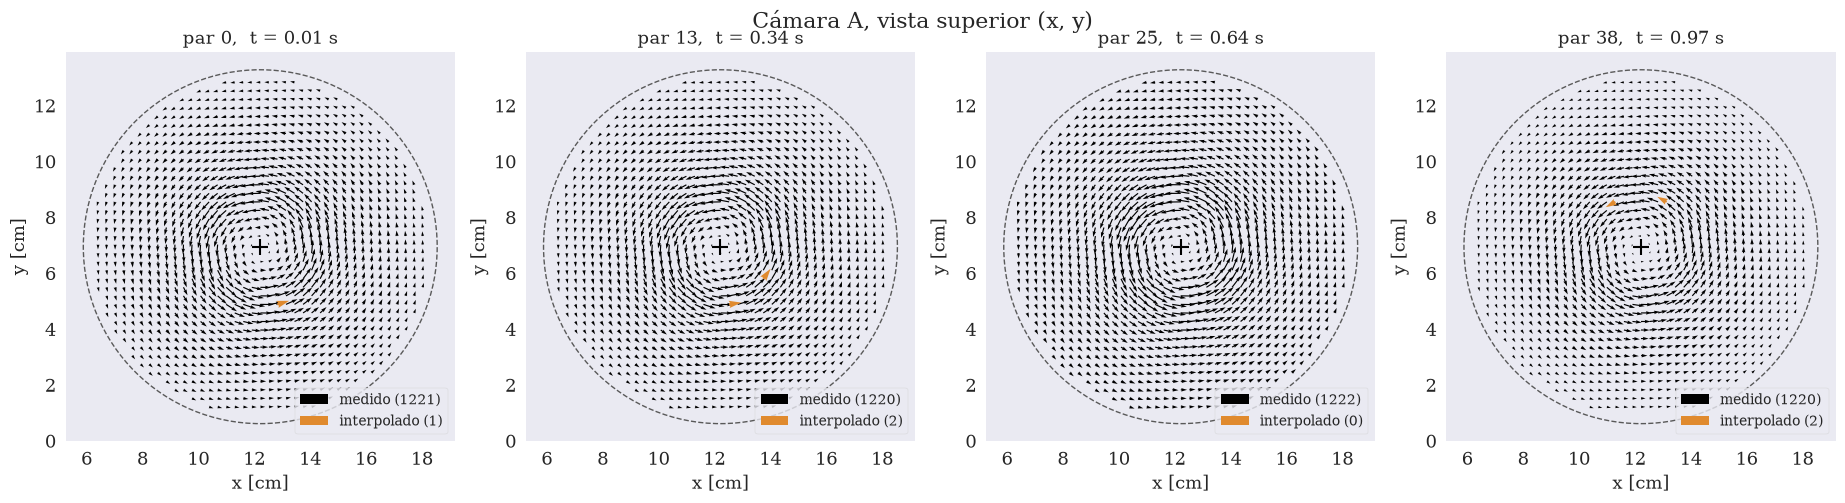

In [4]:
N_PANELES = 4

for L, c in camaras.items():
    todo = c["todo"]
    frames = np.unique(todo["frame"])
    elegidos = frames[np.linspace(0, len(frames) - 1, min(N_PANELES, len(frames))).round().astype(int)]
    escala = np.nanpercentile(np.hypot(todo["u"], todo["v"]), 95) / (1.5 * c["paso"])

    fig, axs = plt.subplots(1, len(elegidos), figsize=(4.6 * len(elegidos), 4.8),
                            constrained_layout=True, squeeze=False)
    for ax, f in zip(axs[0], elegidos):
        d = todo[todo["frame"] == f]
        malo = d["interpolado"] == 1
        for sel, color, ancho, nombre in ((~malo, "k", 0.003, "medido"), (malo, NARANJA, 0.007, "interpolado")):
            ax.quiver(d["x"][sel], d["y"][sel], d["u"][sel], d["v"][sel], angles="xy", scale_units="xy",
                      scale=escala, width=ancho, color=color, label=f"{nombre} ({sel.sum()})")
        decorar(ax, c)
        ax.set_title(f"par {f},  t = {d['t_s'].iloc[0]:.2f} s")
        ax.legend(loc="lower right", fontsize=fontsize - 3)
    fig.suptitle(f"Cámara {L}, vista {c['vista']}")
    plt.show()

## 4. Perfil del vórtice (vistas superiores)

El campo se separa en anillos alrededor del centro, del ancho de una celda de la grilla. Cada
anillo se promedia en cada par y después entre pares. La banda es el desvío estándar entre
pares, o sea cuánto fluctúa en el tiempo.

- `v_θ(r)`: el perfil de velocidad tangencial.
- `ω(r) = v_θ / r`: la velocidad angular, constante en un núcleo que rota como sólido.
- `v_r(r)`: tendría que ser ≈ 0. Si no lo es, el centro está mal marcado o el vórtice se desplaza.

Si la grabación es de la simulación, en gris está el vórtice que se inyectó.
Abajo, `v_θ(r, t)` muestra si el perfil se mantuvo durante toda la grabación.

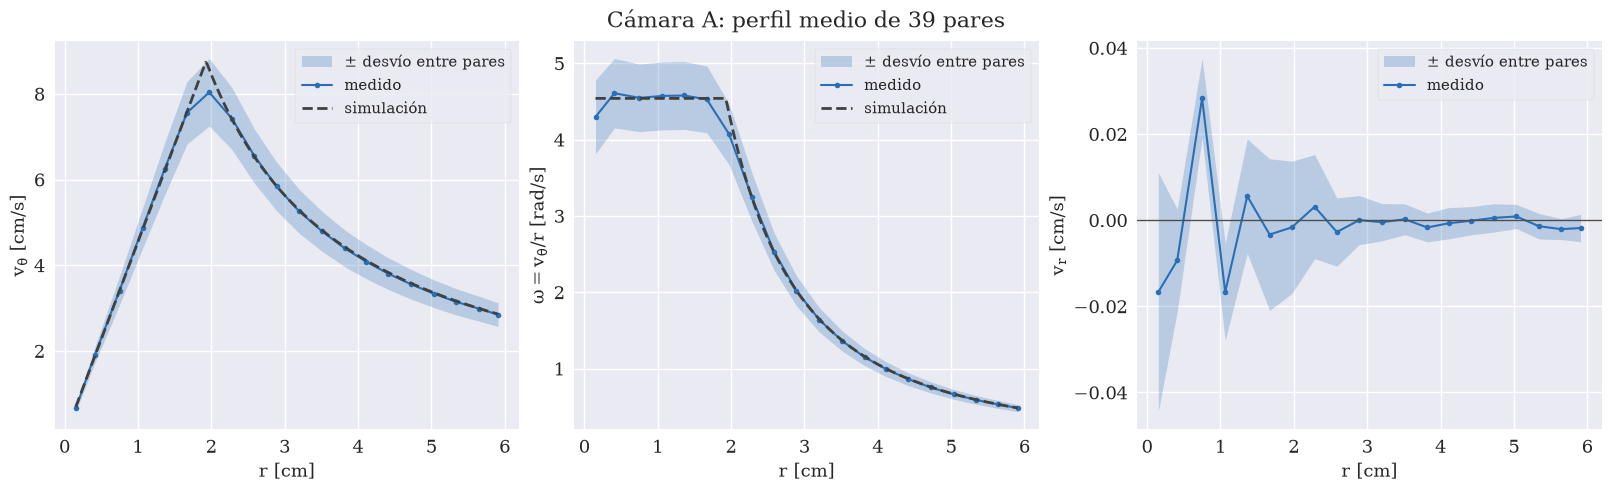

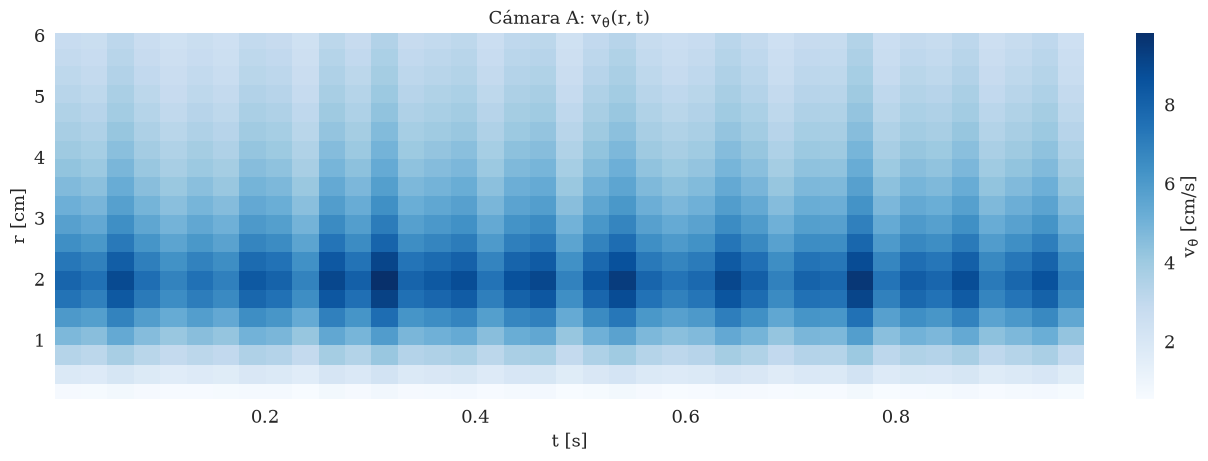

In [5]:
def perfil_por_par(c):
    # v_theta y v_r promediados por anillo en cada par: tabla (anillo, frame)
    df = c["df"].dropna(subset=["vt"])
    anillo = np.floor(df["r"] / c["paso"]).astype(int)
    tabla = df.groupby([anillo, df["frame"]])[["vt", "vr", "t_s"]].mean()
    r = df.groupby(anillo)["r"].mean()
    return r, tabla


def rankine(sim, s, r):
    w0, rc = sim["omega_nucleo_rad_s"], sim["radio_nucleo_px"] * s
    return np.where(r <= rc, w0 * r, w0 * rc**2 / np.maximum(r, rc))


superiores = {L: c for L, c in camaras.items() if "superior" in c["vista"]}
if not superiores:
    print("no hay cámaras con vista superior en este análisis")

for L, c in superiores.items():
    u = c["unidad"]
    r, tabla = perfil_por_par(c)
    g = tabla.groupby(level=0)
    media, desvio = g.mean(), g.std()

    fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    rr = np.linspace(r.min(), r.max(), 300)
    sim = rankine(c["sim"], c["s"], rr) if c["sim"] else None
    curvas = (   # (medido, desvio, simulacion, nombre, unidad)
        (media["vt"], desvio["vt"], sim, r"$v_\theta$", f"{u}/s"),
        (media["vt"] / r, desvio["vt"] / r, None if sim is None else sim / rr, r"$\omega = v_\theta / r$", "rad/s"),
        (media["vr"], desvio["vr"], None, r"$v_r$", f"{u}/s"),
    )
    for ax, (y, e, teoria, nombre, unidad) in zip(axs, curvas):
        ax.fill_between(r, y - e, y + e, color=AZUL, alpha=0.25, lw=0, label="± desvío entre pares")
        ax.plot(r, y, "o-", ms=4, lw=1.5, color=AZUL, label="medido")
        if teoria is not None:
            ax.plot(rr, teoria, "--", lw=2, color="0.25", label="simulación")
        ax.set_xlabel(f"r [{u}]")
        ax.set_ylabel(f"{nombre} [{unidad}]")
        ax.legend(fontsize=fontsize - 2)
    axs[2].axhline(0, color="0.3", lw=1)
    fig.suptitle(f"Cámara {L}: perfil medio de {tabla.index.get_level_values(1).nunique()} pares")
    plt.show()

    mapa = tabla["vt"].unstack(level=0)          # filas = pares, columnas = anillos
    t = tabla["t_s"].groupby(level=1).mean()
    fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
    im = ax.pcolormesh(t.loc[mapa.index], r.loc[mapa.columns], mapa.T, cmap="Blues", shading="nearest")
    fig.colorbar(im, ax=ax, label=rf"$v_\theta$ [{u}/s]")
    ax.grid(False)
    ax.set_xlabel("t [s]")
    ax.set_ylabel(f"r [{u}]")
    ax.set_title(rf"Cámara {L}: $v_\theta(r, t)$")
    plt.show()

## 5. Evolución temporal y calidad

Para cada cámara, par a par: la rapidez media dentro de la región analizada, y el porcentaje de
vectores interpolados. Un salto en el segundo indica que en ese momento la imagen empeoró
(poco glitter, reflejos, desenfoque).

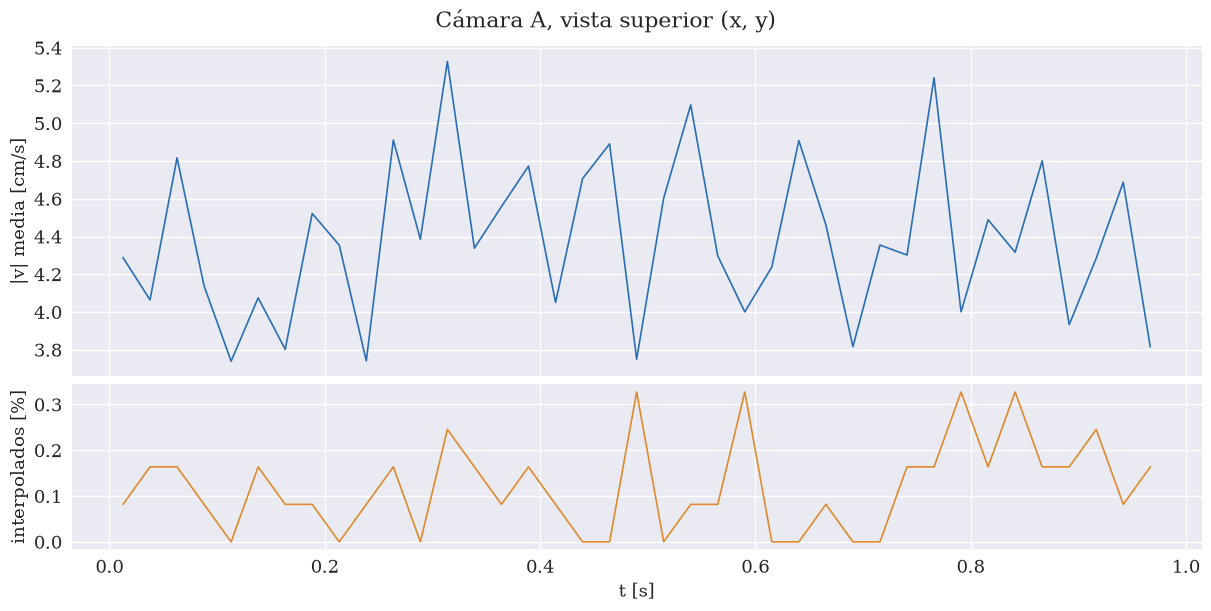

In [6]:
for L, c in camaras.items():
    por_par = c["todo"].groupby("frame").agg(t=("t_s", "mean"), interpolado=("interpolado", "mean"))
    rapidez = np.hypot(c["df"]["u"], c["df"]["v"]).groupby(c["df"]["frame"]).mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
    ax1.plot(por_par["t"].loc[rapidez.index], rapidez, lw=1.2, color=AZUL)
    ax1.set_ylabel(f"|v| media [{c['unidad']}/s]")
    ax2.plot(por_par["t"], 100 * por_par["interpolado"], lw=1.2, color=NARANJA)
    ax2.set_ylabel("interpolados [%]")
    ax2.set_xlabel("t [s]")
    fig.suptitle(f"Cámara {L}, vista {c['vista']}")
    plt.show()